In [3]:
import re
import gc
import html
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from rapidfuzz import fuzz

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

from scipy.sparse import hstack, csr_matrix, save_npz
import joblib

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
tqdm.pandas()

RANDOM_STATE = 42

print("All libraries imported successfully.")

c:\Users\bimal\OneDrive\Desktop\satya\ML Projects\question_similarity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


In [4]:
from pathlib import Path

DATA_DIR = Path(
    r"C:\Users\bimal\OneDrive\Desktop\satya\ML Projects"
    r"\question_similarity\data\raw"
)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

assert TRAIN_PATH.exists(), f"Training file not found: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Test file not found: {TEST_PATH}"

print("Training file:", TRAIN_PATH)
print("Test file:", TEST_PATH)
print("Both files exist.")

Training file: C:\Users\bimal\OneDrive\Desktop\satya\ML Projects\question_similarity\data\raw\train.csv
Test file: C:\Users\bimal\OneDrive\Desktop\satya\ML Projects\question_similarity\data\raw\test.csv
Both files exist.


In [5]:
train_df = pd.read_csv(
    TRAIN_PATH,
    low_memory=False
)

test_df = pd.read_csv(
    TEST_PATH,
    low_memory=False
)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training shape: (404290, 6)
Test shape: (3563475, 3)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


,test_id,question1,question2
0,0,How does the Surface Pro himself 4 compare wit...,Why did Microsoft choose core m3 and not core ...
1,1,Should I have a hair transplant at age 24? How...,How much cost does hair transplant require?
2,2,What but is the best way to send money from Ch...,What you send money to China?
3,3,Which food not emulsifiers?,What foods fibre?
4,4,"How ""aberystwyth"" start reading?",How their can I start reading?


In [6]:
required_train = {
    "question1",
    "question2",
    "is_duplicate"
}

required_test = {
    "question1",
    "question2"
}

missing_train = required_train - set(train_df.columns)
missing_test = required_test - set(test_df.columns)

if missing_train:
    raise ValueError(f"Missing training columns: {missing_train}")

if missing_test:
    raise ValueError(f"Missing test columns: {missing_test}")

if not set(train_df["is_duplicate"].dropna().unique()).issubset({0, 1}):
    raise ValueError("Unexpected target values found.")

print("Dataset schema validated successfully.")
print("\nTraining data types:")
print(train_df.dtypes)

Dataset schema validated successfully.

Training data types:
id               int64
qid1             int64
qid2             int64
question1       object
question2       object
is_duplicate     int64
dtype: object


In [7]:
print("Training missing values:")
display(train_df.isnull().sum().to_frame("missing_count"))

print("\nTest missing values:")
display(test_df.isnull().sum().to_frame("missing_count"))

print("\nExact duplicate training rows:", train_df.duplicated().sum())

print("\nTarget distribution:")
display(train_df["is_duplicate"].value_counts().to_frame("count"))

Training missing values:


,missing_count
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0



Test missing values:


,missing_count
test_id,0
question1,4
question2,6



Exact duplicate training rows: 0

Target distribution:


,count
is_duplicate,
0,255027
1,149263


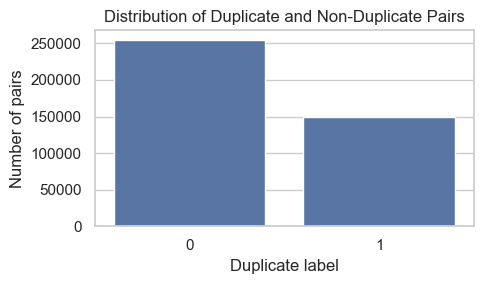

Class proportions:
is_duplicate
0    0.630802
1    0.369198
Name: proportion, dtype: float64


In [9]:
target_counts = train_df["is_duplicate"].value_counts().sort_index()

plt.figure(figsize=(5, 3))
sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values
)

plt.title("Distribution of Duplicate and Non-Duplicate Pairs")
plt.xlabel("Duplicate label")
plt.ylabel("Number of pairs")
plt.tight_layout()
plt.show()

print("Class proportions:")
print(train_df["is_duplicate"].value_counts(normalize=True))

In [11]:
def basic_word_count(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

train_df["q1_word_count"] = train_df["question1"].map(basic_word_count)
train_df["q2_word_count"] = train_df["question2"].map(basic_word_count)

train_df["q1_char_count"] = train_df["question1"].fillna("").str.len()
train_df["q2_char_count"] = train_df["question2"].fillna("").str.len()

display(
    train_df[
        ["q1_word_count", "q2_word_count",
         "q1_char_count", "q2_char_count"]
    ].describe().round(2)
)

,q1_word_count,q2_word_count,q1_char_count,q2_char_count
count,404290.00,404290.00,404290.00,404290.00
mean,10.94,11.18,59.54,60.11
std,5.43,6.31,29.94,33.86
min,0.00,0.00,0.00,0.00
25%,7.00,7.00,39.00,39.00
50%,10.00,10.00,52.00,51.00
75%,13.00,13.00,72.00,72.00
max,125.00,237.00,623.00,1169.00


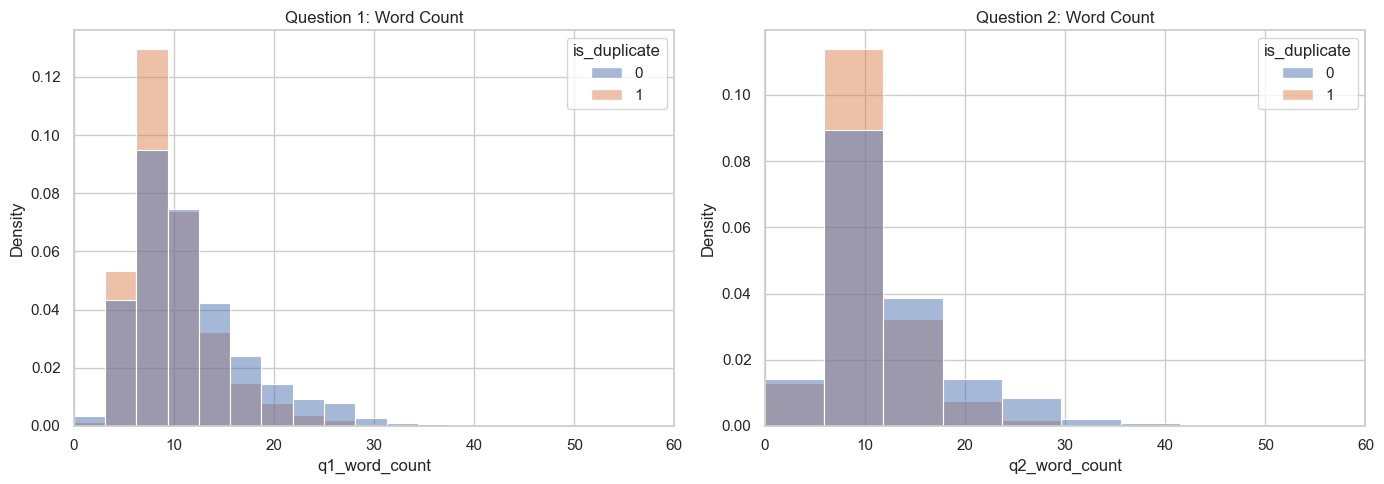

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=train_df,
    x="q1_word_count",
    hue="is_duplicate",
    bins=40,
    stat="density",
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title("Question 1: Word Count")
axes[0].set_xlim(0, 60)

sns.histplot(
    data=train_df,
    x="q2_word_count",
    hue="is_duplicate",
    bins=40,
    stat="density",
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title("Question 2: Word Count")
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.show()

In [13]:
duplicate_examples = train_df[
    train_df["is_duplicate"] == 1
].sample(
    min(5, (train_df["is_duplicate"] == 1).sum()),
    random_state=RANDOM_STATE
)

non_duplicate_examples = train_df[
    train_df["is_duplicate"] == 0
].sample(
    min(5, (train_df["is_duplicate"] == 0).sum()),
    random_state=RANDOM_STATE
)

print("DUPLICATE EXAMPLES")
for _, row in duplicate_examples.iterrows():
    print("\nQ1:", row["question1"])
    print("Q2:", row["question2"])

print("\nNON-DUPLICATE EXAMPLES")
for _, row in non_duplicate_examples.iterrows():
    print("\nQ1:", row["question1"])
    print("Q2:", row["question2"])

DUPLICATE EXAMPLES

Q1: Should I sell an iPhone 6s and buy an iPhone SE?
Q2: Should I buy the iPhone 6s or an SE?

Q1: What happened to the famous people who believed and confirmed the world would end in 2012 and what do they say why it didn't happen?
Q2: What happened to people who sold off all their belongings in 2012 in preparation for the end of the world?

Q1: What are some of the top paying career options after doing a B.Tech in mechanical engineering?
Q2: What is the best field for earning money after completing a B.Tech in mechanical engineering?

Q1: How can I use my time productively during slow day at work?
Q2: What can I do on a boring day at work?

Q1: What is the revenue model for blogging?
Q2: What could be the revenue model for a blogging company?

NON-DUPLICATE EXAMPLES

Q1: Do I legally have to let my employer know that my spouse owns a potential competitor company?
Q2: Should I take a top-up home loan for doing up my new house interiors, if I have the equivalent cash

In [14]:
for df in (train_df, test_df):
    df["question1"] = df["question1"].fillna("").astype(str)
    df["question2"] = df["question2"].fillna("").astype(str)

print("Missing question values handled.")

Missing question values handled.


In [15]:
def normalize_text(text):
    text = html.unescape(str(text))
    text = text.lower()

    # Normalize URLs and email addresses.
    text = re.sub(r"https?://\S+|www\.\S+", " url ", text)
    text = re.sub(
        r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b",
        " email ",
        text
    )

    # Normalize repeated whitespace.
    text = re.sub(r"\s+", " ", text)

    return text.strip()


for df in (train_df, test_df):
    df["q1_clean"] = df["question1"].map(normalize_text)
    df["q2_clean"] = df["question2"].map(normalize_text)

display(
    train_df[["question1", "q1_clean", "question2", "q2_clean"]].head()
)

,question1,q1_clean,question2,q2_clean
0,What is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,what is the story of kohinoor (koh-i-noor) dia...,What would happen if the Indian government sto...,what would happen if the indian government sto...
2,How can I increase the speed of my internet co...,how can i increase the speed of my internet co...,How can Internet speed be increased by hacking...,how can internet speed be increased by hacking...
3,Why am I mentally very lonely? How can I solve...,why am i mentally very lonely? how can i solve...,Find the remainder when [math]23^{24}[/math] i...,find the remainder when [math]23^{24}[/math] i...
4,"Which one dissolve in water quikly sugar, salt...","which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,which fish would survive in salt water?


In [16]:
STOP_WORDS = {
    "a", "an", "the", "is", "are", "was", "were", "am",
    "do", "does", "did", "to", "of", "in", "on", "at",
    "for", "and", "or", "but", "with", "by", "from",
    "how", "what", "when", "where", "who", "why", "which",
    "can", "could", "would", "should", "will", "shall",
    "i", "me", "my", "we", "our", "you", "your", "he",
    "she", "it", "they", "them", "their", "this", "that"
}

def get_tokens(text):
    return re.findall(r"\b\w+\b", text.lower())

def token_features(q1, q2):
    t1 = get_tokens(q1)
    t2 = get_tokens(q2)

    s1 = set(t1)
    s2 = set(t2)

    c1 = {w for w in s1 if w not in STOP_WORDS}
    c2 = {w for w in s2 if w not in STOP_WORDS}

    common = s1 & s2
    common_content = c1 & c2

    return {
        "common_word_count": len(common),
        "common_content_count": len(common_content),
        "common_word_ratio_min": (
            len(common) / min(len(s1), len(s2))
            if min(len(s1), len(s2)) else 0
        ),
        "common_word_ratio_max": (
            len(common) / max(len(s1), len(s2))
            if max(len(s1), len(s2)) else 0
        ),
        "content_word_ratio_min": (
            len(common_content) / min(len(c1), len(c2))
            if min(len(c1), len(c2)) else 0
        ),
        "jaccard_similarity": (
            len(s1 & s2) / len(s1 | s2)
            if s1 | s2 else 0
        ),
        "content_jaccard": (
            len(c1 & c2) / len(c1 | c2)
            if c1 | c2 else 0
        ),
        "unique_word_count": len(s1 ^ s2)
    }

In [17]:
def length_features(q1, q2):
    t1 = get_tokens(q1)
    t2 = get_tokens(q2)

    w1, w2 = len(t1), len(t2)
    c1, c2 = len(q1), len(q2)

    return {
        "q1_word_count": w1,
        "q2_word_count": w2,
        "word_count_diff": abs(w1 - w2),
        "word_count_sum": w1 + w2,
        "word_count_ratio": (
            min(w1, w2) / max(w1, w2)
            if max(w1, w2) else 0
        ),
        "q1_char_count": c1,
        "q2_char_count": c2,
        "char_count_diff": abs(c1 - c2),
        "char_count_ratio": (
            min(c1, c2) / max(c1, c2)
            if max(c1, c2) else 0
        ),
        "q1_avg_word_length": (
            np.mean([len(w) for w in t1]) if t1 else 0
        ),
        "q2_avg_word_length": (
            np.mean([len(w) for w in t2]) if t2 else 0
        )
    }

In [18]:
def fuzzy_features(q1, q2):
    return {
        "fuzz_ratio": fuzz.ratio(q1, q2),
        "fuzz_partial_ratio": fuzz.partial_ratio(q1, q2),
        "fuzz_token_sort_ratio": fuzz.token_sort_ratio(q1, q2),
        "fuzz_token_set_ratio": fuzz.token_set_ratio(q1, q2)
    }

In [19]:
def extract_features(q1, q2):
    features = {}
    features.update(token_features(q1, q2))
    features.update(length_features(q1, q2))
    features.update(fuzzy_features(q1, q2))
    return features


def build_feature_dataframe(df):
    records = [
        extract_features(q1, q2)
        for q1, q2 in tqdm(
            zip(df["q1_clean"], df["q2_clean"]),
            total=len(df),
            desc="Extracting features"
        )
    ]
    return pd.DataFrame(records, index=df.index).astype("float32")


X_hand = build_feature_dataframe(train_df)
X_test_hand = build_feature_dataframe(test_df)

print("Training feature shape:", X_hand.shape)
print("Test feature shape:", X_test_hand.shape)

display(X_hand.head())

Extracting features: 100%|██████████| 3563475/3563475 [04:32<00:00, 13065.78it/s]


Training feature shape: (404290, 23)
Test feature shape: (3563475, 23)


,common_word_count,common_content_count,common_word_ratio_min,common_word_ratio_max,content_word_ratio_min,jaccard_similarity,content_jaccard,unique_word_count,q1_word_count,q2_word_count,...,q1_char_count,q2_char_count,char_count_diff,char_count_ratio,q1_avg_word_length,q2_avg_word_length,fuzz_ratio,fuzz_partial_ratio,fuzz_token_sort_ratio,fuzz_token_set_ratio
0,11.0,5.0,1.000000,0.916667,1.000000,0.916667,0.833333,1.0,14.0,12.0,...,66.0,57.0,9.0,0.863636,3.714286,3.750000,92.682930,99.115044,91.056908,92.727272
1,7.0,4.0,0.700000,0.500000,0.800000,0.411765,0.363636,10.0,10.0,15.0,...,51.0,88.0,37.0,0.579545,3.900000,4.733333,66.187050,77.551018,63.309353,74.074074
2,4.0,2.0,0.400000,0.285714,0.285714,0.200000,0.166667,16.0,14.0,10.0,...,73.0,59.0,14.0,0.808219,4.214286,4.900000,54.545456,56.000000,65.151512,65.151512
3,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,20.0,11.0,13.0,...,50.0,65.0,15.0,0.769231,3.454545,3.615385,33.043480,36.000000,34.782608,31.858408
4,4.0,2.0,0.571429,0.307692,0.500000,0.250000,0.166667,12.0,13.0,7.0,...,76.0,39.0,37.0,0.513158,4.692307,4.571429,45.217392,63.636364,45.217392,46.956520


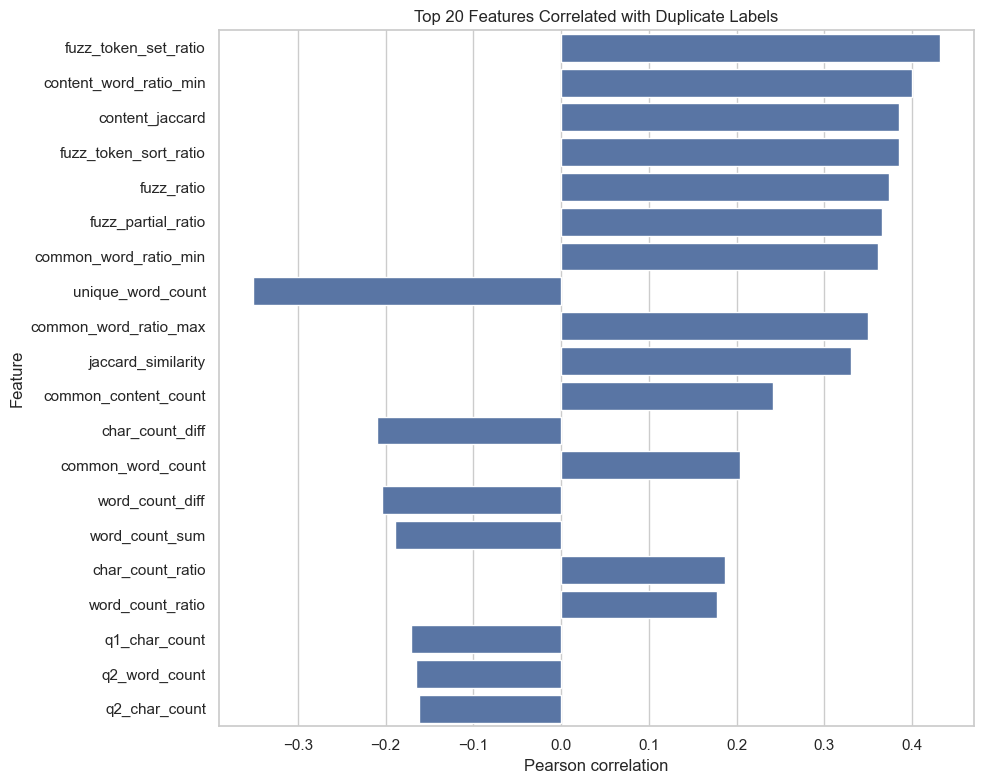

In [21]:
corr_df = X_hand.copy()
corr_df["is_duplicate"] = train_df["is_duplicate"].values

correlations = (
    corr_df.corr(numeric_only=True)["is_duplicate"]
    .drop("is_duplicate")
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=correlations.values[:20],
    y=correlations.index[:20]
)
plt.title("Top 20 Features Correlated with Duplicate Labels")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [22]:
y = train_df["is_duplicate"].astype("int8")

X_train_idx, X_valid_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

y_train = y.iloc[X_train_idx]
y_valid = y.iloc[X_valid_idx]

print("Training samples:", len(X_train_idx))
print("Validation samples:", len(X_valid_idx))
print("Training duplicate rate:", round(y_train.mean(), 4))
print("Validation duplicate rate:", round(y_valid.mean(), 4))

Training samples: 323432
Validation samples: 80858
Training duplicate rate: 0.3692
Validation duplicate rate: 0.3692


In [23]:
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=150_000,
    strip_accents="unicode",
    sublinear_tf=True,
    dtype=np.float32
)

word_vectorizer.fit(
    pd.concat([
        train_df.iloc[X_train_idx]["q1_clean"],
        train_df.iloc[X_train_idx]["q2_clean"]
    ], ignore_index=True)
)

q1_train_word = word_vectorizer.transform(
    train_df.iloc[X_train_idx]["q1_clean"]
)
q2_train_word = word_vectorizer.transform(
    train_df.iloc[X_train_idx]["q2_clean"]
)

q1_valid_word = word_vectorizer.transform(
    train_df.iloc[X_valid_idx]["q1_clean"]
)
q2_valid_word = word_vectorizer.transform(
    train_df.iloc[X_valid_idx]["q2_clean"]
)

q1_test_word = word_vectorizer.transform(test_df["q1_clean"])
q2_test_word = word_vectorizer.transform(test_df["q2_clean"])

print("Word vocabulary:", len(word_vectorizer.vocabulary_))

Word vocabulary: 150000


In [24]:
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=3,
    max_features=100_000,
    sublinear_tf=True,
    dtype=np.float32
)

char_vectorizer.fit(
    pd.concat([
        train_df.iloc[X_train_idx]["q1_clean"],
        train_df.iloc[X_train_idx]["q2_clean"]
    ], ignore_index=True)
)

q1_train_char = char_vectorizer.transform(
    train_df.iloc[X_train_idx]["q1_clean"]
)
q2_train_char = char_vectorizer.transform(
    train_df.iloc[X_train_idx]["q2_clean"]
)

q1_valid_char = char_vectorizer.transform(
    train_df.iloc[X_valid_idx]["q1_clean"]
)
q2_valid_char = char_vectorizer.transform(
    train_df.iloc[X_valid_idx]["q2_clean"]
)

q1_test_char = char_vectorizer.transform(test_df["q1_clean"])
q2_test_char = char_vectorizer.transform(test_df["q2_clean"])

print("Character vocabulary:", len(char_vectorizer.vocabulary_))

Character vocabulary: 100000


In [30]:
import numpy as np
from scipy.sparse import csr_matrix

def pairwise_cosine_similarity_batched(
    q1_matrix,
    q2_matrix,
    batch_size=128
):
    n_samples = q1_matrix.shape[0]
    similarities = np.empty(n_samples, dtype=np.float32)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)

        q1_batch = q1_matrix[start:end]
        q2_batch = q2_matrix[start:end]

        # Compute similarity only for the current batch
        similarities[start:end] = np.asarray(
            q1_batch.multiply(q2_batch).sum(axis=1)
        ).ravel()

    return similarities


def combine_text_features(
    q1_word, q2_word,
    q1_char, q2_char,
    batch_size=128
):
    word_similarity = pairwise_cosine_similarity_batched(
        q1_word, q2_word, batch_size
    )

    char_similarity = pairwise_cosine_similarity_batched(
        q1_char, q2_char, batch_size
    )

    return csr_matrix(
        np.column_stack([
            word_similarity,
            char_similarity
        ]),
        dtype=np.float32
    )


# Training features
X_train_text = combine_text_features(
    q1_train_word, q2_train_word,
    q1_train_char, q2_train_char
)

# Validation features
X_valid_text = combine_text_features(
    q1_valid_word, q2_valid_word,
    q1_valid_char, q2_valid_char
)

# Test features
X_test_text = combine_text_features(
    q1_test_word, q2_test_word,
    q1_test_char, q2_test_char
)

print("Training features:", X_train_text.shape)
print("Validation features:", X_valid_text.shape)
print("Test features:", X_test_text.shape)

Training features: (323432, 2)
Validation features: (80858, 2)
Test features: (3563475, 2)


In [33]:
# Combine training and validation features only

from scipy.sparse import hstack, csr_matrix
import numpy as np

def combine_final_features(text_features, hand_features):
    return hstack(
        [
            text_features,
            csr_matrix(
                hand_features,
                dtype=np.float32
            )
        ],
        format="csr",
        dtype=np.float32
    )


X_train_final = combine_final_features(
    X_train_text,
    X_train_hand
)

X_valid_final = combine_final_features(
    X_valid_text,
    X_valid_hand
)

print("Training matrix:", X_train_final.shape)
print("Validation matrix:", X_valid_final.shape)

Training matrix: (323432, 25)
Validation matrix: (80858, 25)


In [34]:
baseline_model = LogisticRegression(
    C=1.0,
    solver="liblinear",
    max_iter=500,
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train_hand, y_train)

baseline_prob = baseline_model.predict_proba(
    X_valid_hand
)[:, 1]

print("Baseline model trained.")
print("Validation log loss:", log_loss(y_valid, baseline_prob))

Baseline model trained.
Validation log loss: 0.5134574627525716


In [35]:
hybrid_model = LogisticRegression(
    C=1.0,
    solver="saga",
    max_iter=300,
    tol=1e-3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hybrid_model.fit(X_train_final, y_train)

hybrid_prob = hybrid_model.predict_proba(
    X_valid_final
)[:, 1]

print("Hybrid model trained.")
print("Validation log loss:", log_loss(y_valid, hybrid_prob))

Hybrid model trained.
Validation log loss: 0.4975546362734657


In [36]:
def evaluate_model(name, y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    return {
        "Model": name,
        "Log Loss": log_loss(y_true, probabilities),
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_true, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }


results = pd.DataFrame([
    evaluate_model(
        "Engineered Features",
        y_valid,
        baseline_prob
    ),
    evaluate_model(
        "Hybrid TF-IDF + Engineered",
        y_valid,
        hybrid_prob
    )
])

display(results.round(5))

,Model,Log Loss,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Engineered Features,0.51346,0.70504,0.60982,0.5583,0.58293,0.79042
1,Hybrid TF-IDF + Engineered,0.49755,0.72237,0.63465,0.5845,0.60854,0.80980


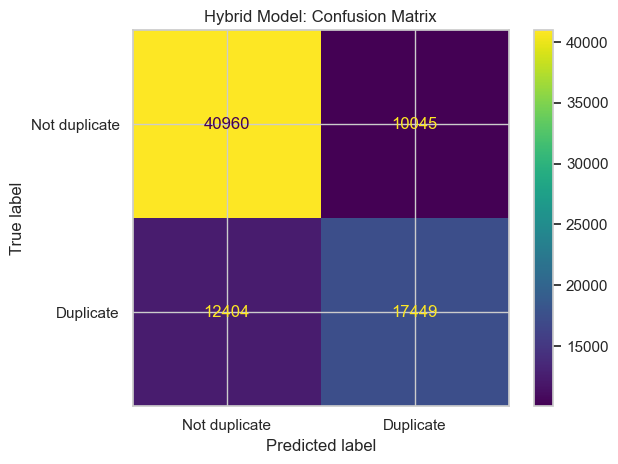

               precision    recall  f1-score   support

Not duplicate       0.77      0.80      0.78     51005
    Duplicate       0.63      0.58      0.61     29853

     accuracy                           0.72     80858
    macro avg       0.70      0.69      0.70     80858
 weighted avg       0.72      0.72      0.72     80858



In [37]:
hybrid_pred = (hybrid_prob >= 0.5).astype(int)

cm = confusion_matrix(y_valid, hybrid_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not duplicate", "Duplicate"]
)

disp.plot(values_format="d")
plt.title("Hybrid Model: Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(
    y_valid,
    hybrid_pred,
    target_names=["Not duplicate", "Duplicate"],
    zero_division=0
))

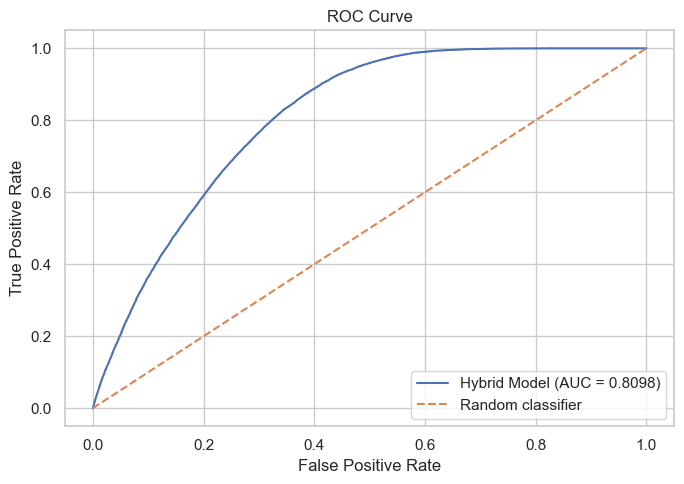

In [38]:
fpr, tpr, thresholds = roc_curve(y_valid, hybrid_prob)
auc = roc_auc_score(y_valid, hybrid_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Hybrid Model (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

,Threshold,Precision,Recall,F1
0,0.1,0.4692,0.9964,0.6380
1,0.2,0.5261,0.9626,0.6804
2,0.3,0.5673,0.8824,0.6906
3,0.4,0.6022,0.7528,0.6691
4,0.5,0.6346,0.5845,0.6085
5,0.6,0.6728,0.4006,0.5022
6,0.7,0.7046,0.2208,0.3363
7,0.8,0.7387,0.0849,0.1524
8,0.9,0.7560,0.0106,0.0209


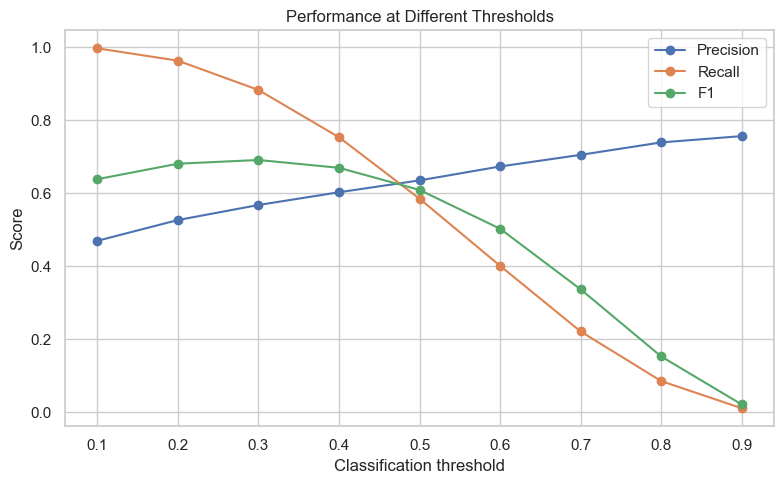

In [39]:
threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.1):
    predictions = (hybrid_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 1),
        "Precision": precision_score(
            y_valid, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_valid, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_valid, predictions, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(4))

plt.figure(figsize=(8, 5))
for metric in ["Precision", "Recall", "F1"]:
    plt.plot(
        threshold_df["Threshold"],
        threshold_df[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Performance at Different Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
from pathlib import Path
import joblib

MODEL_DIR = Path(
    r"C:\Users\bimal\OneDrive\Desktop\satya\ML Projects"
    r"\question_similarity\models"
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)

artifacts = {
    "model": hybrid_model,
    "word_vectorizer": word_vectorizer,
    "char_vectorizer": char_vectorizer,
    "hand_scaler": hand_scaler,
    "feature_columns": list(X_hand.columns),
    "threshold": 0.5
}

MODEL_PATH = MODEL_DIR / "quora_similarity_model.joblib"

joblib.dump(artifacts, MODEL_PATH, compress=3)

print(f"Model saved successfully at:\n{MODEL_PATH}")

Model saved successfully at:
C:\Users\bimal\OneDrive\Desktop\satya\ML Projects\question_similarity\models\quora_similarity_model.joblib


In [41]:
artifacts = joblib.load(
    MODEL_DIR / "quora_similarity_model.joblib"
)

loaded_model = artifacts["model"]
print("Model loaded successfully.")

Model loaded successfully.


In [42]:
def predict_similarity(question1, question2, artifacts):
    q1 = normalize_text(question1)
    q2 = normalize_text(question2)

    features = pd.DataFrame([
        extract_features(q1, q2)
    ])

    features = features[
        artifacts["feature_columns"]
    ]

    hand = artifacts["hand_scaler"].transform(features)

    q1_word = artifacts["word_vectorizer"].transform([q1])
    q2_word = artifacts["word_vectorizer"].transform([q2])

    q1_char = artifacts["char_vectorizer"].transform([q1])
    q2_char = artifacts["char_vectorizer"].transform([q2])

    text_features = combine_text_features(
        q1_word, q2_word, q1_char, q2_char
    )

    combined = hstack(
        [text_features, csr_matrix(hand.astype(np.float32))],
        format="csr",
        dtype=np.float32
    )

    probability = artifacts["model"].predict_proba(combined)[0, 1]
    threshold = artifacts["threshold"]

    return {
        "probability": float(probability),
        "is_duplicate": bool(probability >= threshold)
    }

In [45]:
result = predict_similarity(
    "How can I learn Python?",
    "What is the best way to learn Python?",
    artifacts
)

print(f"Duplicate probability: {result['probability']:.4f}")
print(
    "Prediction:",
    "Duplicate" if result["is_duplicate"] else "Not duplicate"
)

Duplicate probability: 0.5422
Prediction: Duplicate


In [48]:

import numpy as np
from scipy.sparse import hstack, csr_matrix

def predict_test_in_batches(
    model,
    q1_word,
    q2_word,
    q1_char,
    q2_char,
    hand_features,
    batch_size=256
):
    n_samples = q1_word.shape[0]
    predictions = np.empty(n_samples, dtype=np.float32)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)

        # Calculate word and character similarity
        word_sim = pairwise_cosine_similarity_batched(
            q1_word[start:end],
            q2_word[start:end],
            batch_size=128
        )

        char_sim = pairwise_cosine_similarity_batched(
            q1_char[start:end],
            q2_char[start:end],
            batch_size=128
        )

        # Combine text similarity features
        text_batch = csr_matrix(
            np.column_stack([word_sim, char_sim]),
            dtype=np.float32
        )

        # Combine with engineered features
        hand_batch = csr_matrix(
            hand_features[start:end],
            dtype=np.float32
        )

        X_batch = hstack(
            [text_batch, hand_batch],
            format="csr",
            dtype=np.float32
        )

        # Predict probabilities
        predictions[start:end] = model.predict_proba(X_batch)[:, 1]

        del text_batch, hand_batch, X_batch

        if end % (batch_size * 10) == 0 or end == n_samples:
            print(f"Processed {end:,}/{n_samples:,} rows")

    return predictions

In [50]:
    
from pathlib import Path
import pandas as pd

test_probabilities = predict_test_in_batches(
    loaded_model,
    q1_test_word,
    q2_test_word,
    q1_test_char,
    q2_test_char,
    X_test_hand_scaled,
    batch_size=256
)

id_col = (
    "test_id" if "test_id" in test_df.columns
    else "id"
)

submission = pd.DataFrame({
    id_col: test_df[id_col].to_numpy(),
    "is_duplicate": test_probabilities
})

# Save submission to the project directory
submission_path = Path(
    r"C:\Users\bimal\OneDrive\Desktop\satya\ML Projects"
    r"\question_similarity\submission.csv"
)

submission.to_csv(submission_path, index=False)

print("Submission generated:", submission_path)
print("Submission shape:", submission.shape)
display(submission.head())

Processed 2,560/3,563,475 rows
Processed 5,120/3,563,475 rows
Processed 7,680/3,563,475 rows
Processed 10,240/3,563,475 rows
Processed 12,800/3,563,475 rows
Processed 15,360/3,563,475 rows
Processed 17,920/3,563,475 rows
Processed 20,480/3,563,475 rows
Processed 23,040/3,563,475 rows
Processed 25,600/3,563,475 rows
Processed 28,160/3,563,475 rows
Processed 30,720/3,563,475 rows
Processed 33,280/3,563,475 rows
Processed 35,840/3,563,475 rows
Processed 38,400/3,563,475 rows
Processed 40,960/3,563,475 rows
Processed 43,520/3,563,475 rows
Processed 46,080/3,563,475 rows
Processed 48,640/3,563,475 rows
Processed 51,200/3,563,475 rows
Processed 53,760/3,563,475 rows
Processed 56,320/3,563,475 rows
Processed 58,880/3,563,475 rows
Processed 61,440/3,563,475 rows
Processed 64,000/3,563,475 rows
Processed 66,560/3,563,475 rows
Processed 69,120/3,563,475 rows
Processed 71,680/3,563,475 rows
Processed 74,240/3,563,475 rows
Processed 76,800/3,563,475 rows
Processed 79,360/3,563,475 rows
Processed 8

,test_id,is_duplicate
0,0,0.174808
1,1,0.644816
2,2,0.718723
3,3,0.034389
4,4,0.205949
